# PAR Take-Home Assignment – Candidate Notebook

Welcome. This notebook is for your implementation of a **Person Attribute Recognition (PAR)** model as your take-home assignment.

## Objective
Train a model to predict:
- 'age-group'
- `gender (0=male, 1=female)`
- `headgear type`
- `upper_body_clothing_color`
- `lower_body_clothing_color`
- `glasses`

You are encouraged to keep the implementation clean, practical, and reproducible.

## Deliverables
By the end of this notebook, please include:
1. a trained model,
2. validation metrics,
3. a short discussion of your approach and trade-offs,
4. a CSV of test predictions.
5. A few annotated test sample crops

In [1]:
#Data extraction
!pip install -q onedrivedownloader
!pip install -q timm "albumentations>=1.4.18,<2.1" onedrivedownloader scikit-learn seaborn

In [2]:
from onedrivedownloader import download

In [3]:
from google.colab import drive
import shutil
import zipfile
import os

# 1. Mount Drive
try:
    drive.mount('/content/drive', force_remount=True)
except ValueError as e:
    print(f"Error mounting Google Drive: {e}")
    print("Please ensure you authorize Google Drive access when prompted.")
    print("If this error persists, try running `drive.mount('/content/drive')` in a new cell and follow the instructions.")
    # Exit or handle the error appropriately if mounting is crucial
    # For now, we'll let the script continue, but subsequent steps might fail.

# 2. Paths
drive_zip_path = '/content/drive/MyDrive/Data/data.zip'
local_zip_path = '/content/data.zip'
extract_dir = '/content/dataset'

# 3. CLEANUP: Delete the corrupted file from previous attempts
if os.path.exists(local_zip_path):
    print("Removing old/corrupted local file...")
    os.remove(local_zip_path)

if os.path.exists(extract_dir):
    print("Removing old extraction folder...")
    shutil.rmtree(extract_dir)

# 4. Copy the REAL zip file from Drive to local storage
print("Transferring fresh zip from Google Drive to local runtime...")
shutil.copy(drive_zip_path, local_zip_path)

# 5. UNZIP IT
print("Unzipping the data...")
with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print("Extraction complete! Data is ready.")

# 6. Verify
if os.path.exists(extract_dir):
    print(f"\nFiles ready inside {extract_dir}:")
    print(os.listdir(extract_dir)[:10])

Mounted at /content/drive
Transferring fresh zip from Google Drive to local runtime...
Unzipping the data...
Extraction complete! Data is ready.

Files ready inside /content/dataset:
['data']


In [4]:
import os
import glob
import random
import zipfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import cv2
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [5]:
import os
import glob
import zipfile
import shutil
import pandas as pd
from pathlib import Path
from google.colab import drive

# 1. Mount Drive (just in case the runtime disconnected)
drive.mount('/content/drive')

local_zip = '/content/data.zip'
drive_zip = '/content/drive/MyDrive/Data/data.zip'
extract_dir = '/content/dataset'

# 2. Ensure the zip is in local storage
if not os.path.exists(local_zip) and os.path.exists(drive_zip):
    print("Copying zip from Drive...")
    shutil.copy(drive_zip, local_zip)

# 3. Ensure the zip is EXTRACTED
if os.path.exists(local_zip):
    if not os.path.exists(extract_dir) or len(os.listdir(extract_dir)) == 0:
        print("Extracting zip file to free the CSV...")
        with zipfile.ZipFile(local_zip, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print("Extraction complete!")
else:
    print("ERROR: Could not find data.zip. Check your Google Drive paths!")

# 4. NOW run your robust CSV logic
csv_candidates = glob.glob(f"{extract_dir}/**/*.csv", recursive=True)
print("\nCSV candidates found:", csv_candidates)

if len(csv_candidates) == 0:
    raise FileNotFoundError("Could not find any CSV files. The zip might be empty or structured differently.")

# Safely grab the final_labels.csv
csv_path = [p for p in csv_candidates if p.endswith("final_labels.csv")][0]
print("Using CSV:", csv_path)

# Load the DataFrame
df = pd.read_csv(csv_path)
print("Columns:", df.columns.tolist())
print("Rows:", len(df))

# Dynamically resolve absolute image paths
base_dir = Path(csv_path).parent
df["image_path"] = df["imgs"].apply(lambda p: str(base_dir / p))

# Verify all images exist
missing = (~df["image_path"].apply(lambda p: Path(p).exists())).sum()
print("Missing images:", int(missing))
assert missing == 0, "Some image paths are missing. Check extraction path."

print("\nSUCCESS! DataFrame is perfectly loaded and ready for training.")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

CSV candidates found: ['/content/dataset/data/final_labels.csv']
Using CSV: /content/dataset/data/final_labels.csv
Columns: ['imgs', 'Age', 'Gender', 'UBClothingColor', 'LBClothingColor', 'Glasses', 'Headgear']
Rows: 70000
Missing images: 0

SUCCESS! DataFrame is perfectly loaded and ready for training.


,imgs,Age,Gender,UBClothingColor,LBClothingColor,Glasses,Headgear,image_path
0,images/0002_c1s1_000451_03.jpg,Adult,0,Red,Blue,1,NoHeadgear,/content/dataset/data/images/0002_c1s1_000451_...
1,images/0002_c1s1_000551_01.jpg,Adult,0,Red,Blue,0,NoHeadgear,/content/dataset/data/images/0002_c1s1_000551_...
2,images/0002_c1s1_000776_01.jpg,Adult,0,Red,Blue,1,NoHeadgear,/content/dataset/data/images/0002_c1s1_000776_...
3,images/0002_c1s1_000801_01.jpg,Adult,0,Red,Blue,1,NoHeadgear,/content/dataset/data/images/0002_c1s1_000801_...
4,images/0002_c1s1_069056_02.jpg,Adult,0,Red,Blue,1,NoHeadgear,/content/dataset/data/images/0002_c1s1_069056_...


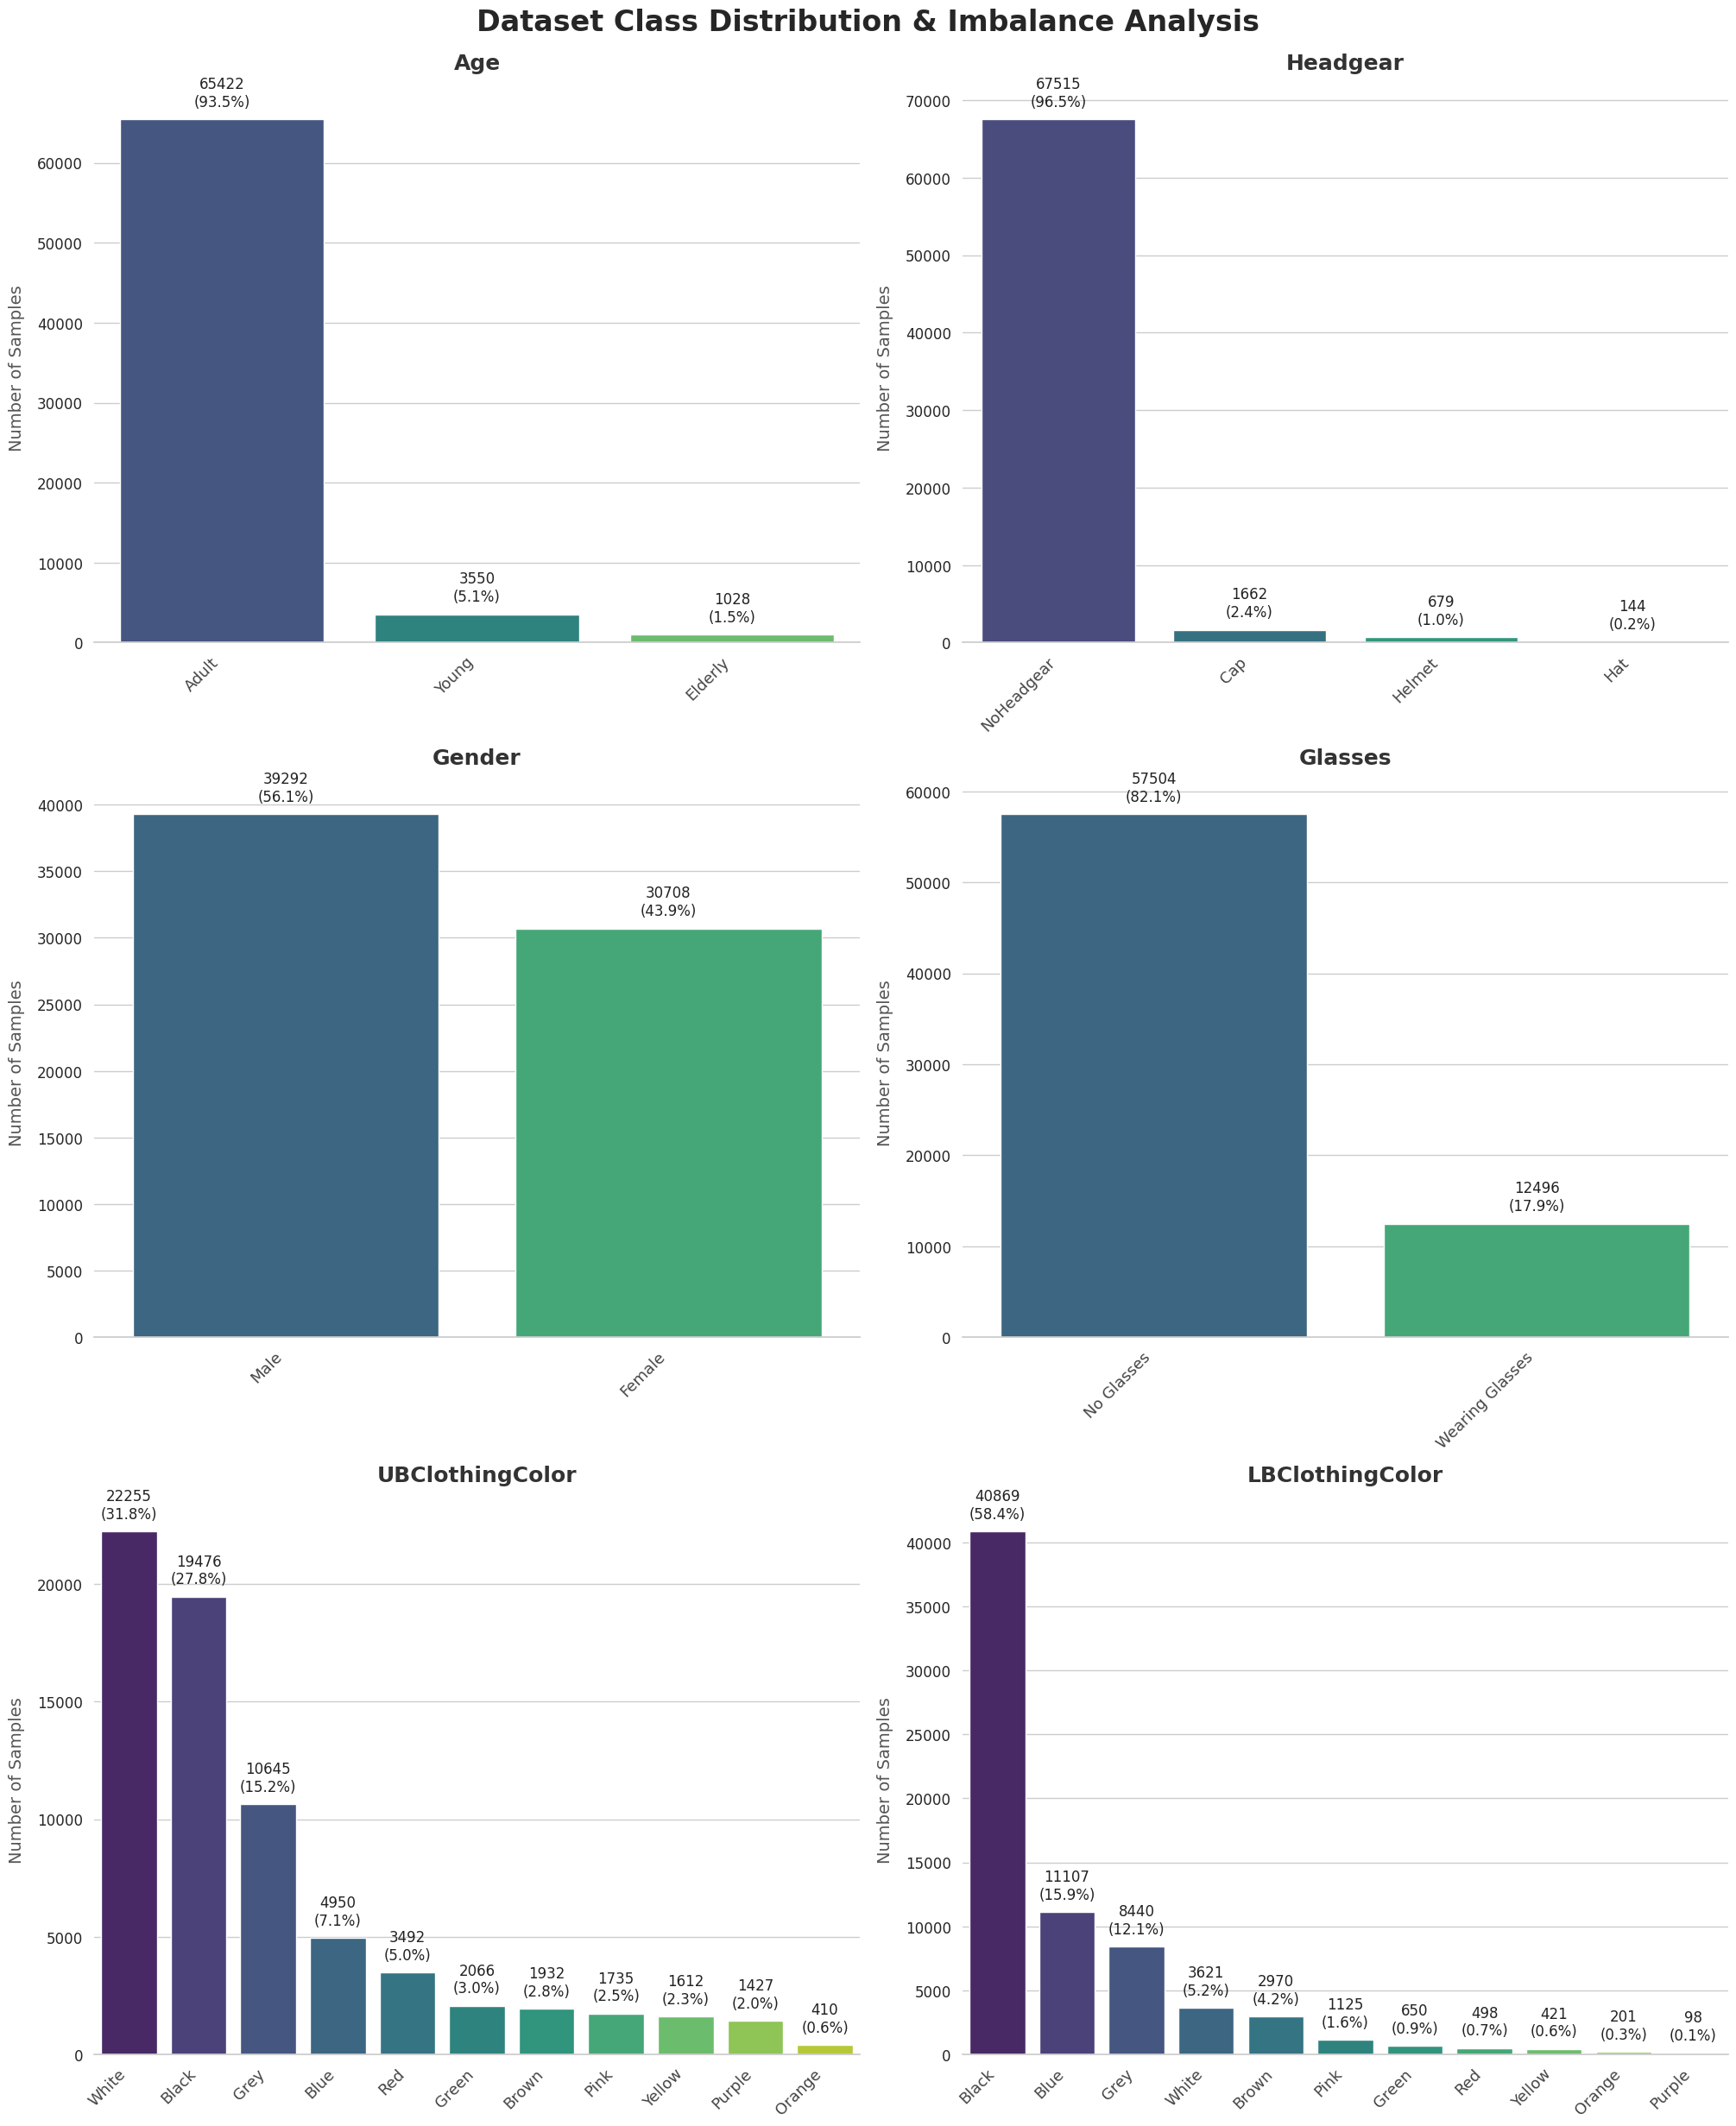

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

#'df' is loaded final_labels.csv
target_cols = ["Age", "Headgear", "Gender", "Glasses", "UBClothingColor", "LBClothingColor"]

label_mappings = {
    "Gender": {0: "Male", 1: "Female"},
    "Glasses": {0: "No Glasses", 1: "Wearing Glasses"}
}
sns.set_theme(style="whitegrid", font_scale=1.1)

# Switch to 2 columns so wide categories (Clothing Colors) don't get squished!
n_cols = 2
n_rows = math.ceil(len(target_cols) / n_cols)

# Use constrained_layout=True (much smarter than tight_layout)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 8 * n_rows), constrained_layout=True)
axes = axes.flatten()

# Add an overarching professional Title
fig.suptitle("Dataset Class Distribution & Imbalance Analysis", fontsize=24, fontweight='bold', y=1.02)

for i, col in enumerate(target_cols):
    ax = axes[i]

    # Translate data
    if col in label_mappings:
        plot_data = df[col].map(label_mappings[col]).fillna(df[col])
    else:
        plot_data = df[col]

    counts = plot_data.value_counts()

    # Draw plot with modern 'viridis' gradient. legend=False keeps it clean.
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis", hue=counts.index, legend=False)

    # Styling the axes
    ax.set_title(f"{col}", fontsize=18, fontweight='bold', pad=20, color="#333333")
    ax.set_ylabel("Number of Samples", fontsize=14, color="#555555", labelpad=10)
    ax.set_xlabel("")

    # Clean up the borders (removes top, right, and left bounding lines)
    sns.despine(ax=ax, left=True, bottom=False)

    # Crisp, angled labels anchored properly
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=13, color="#444444")

    # Premium Annotations (Slightly larger, darker text for readability)
    total = len(df[col].dropna())
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}\n({height/total:.1%})',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=12, fontweight='500', color="#222222",
                        xytext=(0, 8), textcoords='offset points')

# Cleanly remove any empty subplot grids if we have an odd number of charts
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Save and render
plt.savefig("EDA", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

### Initial Approach: Naive Stratified Split (The Identity Leakage Trap)
*Note: I initially attempted a standard `StratifiedShuffleSplit` (code below) to preserve the exact class ratios across Train, Val, and Test. However, upon inspecting the dataset filenames (e.g., `0002_c1s1...`), I realized this dataset is a Re-ID corpus in disguise (following the Market-1501 convention). With 70k images but fewer unique identities, standard stratification would cause **Severe Identity Leakage**—the model would memorize individuals instead of learning visual attributes.*

*I am keeping this code block here to document my thought process, but **I have bypassed it in favor of the Group-Aware Seed Search in the next cell**.*

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

# Assume 'df' is already loaded from final_labels.csv
df = df.copy()

print("Initiating Group-Aware Seed Search for the most stable leakage-safe split...")

# =====================================================================
# DROP-IN HELPER: AUTO-SEARCH BEST SEED + SPLIT REPORT TABLE
# =====================================================================
df["group_id"] = df["imgs"].str.extract(r"images/(\d+)", expand=False)
assert df["group_id"].notna().all(), "Failed to extract some group IDs."

stratify_cols = ["Age", "Headgear", "Gender", "Glasses", "UBClothingColor", "LBClothingColor"]

def max_prop_diff(df_a, df_b, col):
    """Maximum absolute class-proportion drift for one attribute."""
    prop_a = df_a[col].value_counts(normalize=True)
    prop_b = df_b[col].value_counts(normalize=True)
    keys = sorted(set(prop_a.index).union(prop_b.index))
    return max(abs(prop_a.get(k, 0.0) - prop_b.get(k, 0.0)) for k in keys)

def run_group_split_for_seed(frame, seed):
    """Returns train/val/test DataFrames for one seed with strict group isolation."""
    gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    train_idx, temp_idx = next(gss1.split(frame, groups=frame["group_id"]))
    train_part = frame.iloc[train_idx].copy()
    temp_part = frame.iloc[temp_idx].copy()

    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
    val_idx, test_idx = next(gss2.split(temp_part, groups=temp_part["group_id"]))
    val_part = temp_part.iloc[val_idx].copy()
    test_part = temp_part.iloc[test_idx].copy()

    return train_part, val_part, test_part

search_rows = []
for seed in range(0, 101):
    tr, va, te = run_group_split_for_seed(df, seed)

    drift_values = {f"drift_{col}": max_prop_diff(tr, te, col) for col in stratify_cols}
    mean_drift = float(np.mean(list(drift_values.values())))

    size_penalty = (
        abs(len(tr) / len(df) - 0.8)
        + abs(len(va) / len(df) - 0.1)
        + abs(len(te) / len(df) - 0.1)
    )

    # Weighted objective: prioritize distribution fidelity, keep split sizes near 80/10/10
    total_score = mean_drift + (0.5 * size_penalty)

    search_rows.append({
        "seed": seed,
        "score": total_score,
        "mean_drift": mean_drift,
        "size_penalty": size_penalty,
        "train_rows": len(tr),
        "val_rows": len(va),
        "test_rows": len(te),
        **drift_values,
    })

seed_report_df = pd.DataFrame(search_rows).sort_values(["score", "size_penalty"]).reset_index(drop=True)
print("\nTop seed candidates (lower score is better):")
display(seed_report_df.head(10))

best_seed = int(seed_report_df.loc[0, "seed"])
print(f"\n✅ Selected best seed: {best_seed}")

# Apply the selected seed
train_df, val_df, test_df = run_group_split_for_seed(df, best_seed)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Leakage checks
train_groups = set(train_df["group_id"])
val_groups = set(val_df["group_id"])
test_groups = set(test_df["group_id"])

overlap_train_val = len(train_groups & val_groups)
overlap_train_test = len(train_groups & test_groups)
overlap_val_test = len(val_groups & test_groups)

# Final split report table
total_rows = len(df)
split_report_df = pd.DataFrame([
    {
        "split": "train",
        "rows": len(train_df),
        "ratio": len(train_df) / total_rows,
        "unique_groups": train_df["group_id"].nunique(),
    },
    {
        "split": "val",
        "rows": len(val_df),
        "ratio": len(val_df) / total_rows,
        "unique_groups": val_df["group_id"].nunique(),
    },
    {
        "split": "test",
        "rows": len(test_df),
        "ratio": len(test_df) / total_rows,
        "unique_groups": test_df["group_id"].nunique(),
    },
])

print("\n🔒 Leakage Check (must all be zero):")
print(f"Train-Val overlap:  {overlap_train_val}")
print(f"Train-Test overlap: {overlap_train_test}")
print(f"Val-Test overlap:   {overlap_val_test}")

print("\n📊 Final Split Report Table:")
display(split_report_df)

print("\nPer-attribute train-vs-test drift for selected seed:")
selected_drift_df = pd.DataFrame({
    "attribute": stratify_cols,
    "max_abs_prop_diff": [max_prop_diff(train_df, test_df, c) for c in stratify_cols],
})
display(selected_drift_df)

print("\n✅ Group-aware split complete. Downstream pipeline should now use train_df / val_df / test_df.")

# Drop the helper `group_id` column so it does not pollute downstream frames.
for _split in (train_df, val_df, test_df):
    if "group_id" in _split.columns:
        _split.drop(columns=["group_id"], inplace=True)


Initiating Group-Aware Seed Search for the most stable leakage-safe split...

Top seed candidates (lower score is better):


,seed,score,mean_drift,size_penalty,train_rows,val_rows,test_rows,drift_Age,drift_Headgear,drift_Gender,drift_Glasses,drift_UBClothingColor,drift_LBClothingColor
0,27,0.006694,0.005822,0.001743,56040,6939,7021,0.000408,0.001162,0.002726,0.000074,0.015537,0.015027
1,32,0.006728,0.006485,0.000486,55991,6992,7017,0.005147,0.003620,0.001283,0.002908,0.005148,0.020804
2,28,0.007147,0.005118,0.004057,56105,7037,6858,0.005492,0.001491,0.004795,0.000769,0.012730,0.005434
3,84,0.007350,0.005693,0.003314,55886,6998,7116,0.003336,0.003652,0.003606,0.003021,0.012942,0.007598
4,55,0.007653,0.005910,0.003486,56029,7093,6878,0.005557,0.001231,0.004731,0.003563,0.012295,0.008084
5,69,0.007786,0.007272,0.001029,56005,6964,7031,0.002679,0.001737,0.008012,0.000495,0.019116,0.011591
6,85,0.007967,0.006367,0.003200,55893,7112,6995,0.000457,0.002938,0.001475,0.002555,0.015599,0.015175
7,57,0.008043,0.005401,0.005286,55815,7031,7154,0.002174,0.001321,0.004833,0.001382,0.012746,0.009948
8,87,0.008191,0.006906,0.002571,56090,6911,6999,0.002136,0.003902,0.001376,0.010761,0.014464,0.008796
9,62,0.008592,0.007921,0.001343,55973,6980,7047,0.002423,0.005722,0.000732,0.005922,0.009095,0.023632



✅ Selected best seed: 27

🔒 Leakage Check (must all be zero):
Train-Val overlap:  0
Train-Test overlap: 0
Val-Test overlap:   0

📊 Final Split Report Table:


,split,rows,ratio,unique_groups
0,train,56040,0.800571,47844
1,val,6939,0.099129,5981
2,test,7021,0.100300,5981



Per-attribute train-vs-test drift for selected seed:


,attribute,max_abs_prop_diff
0,Age,0.000408
1,Headgear,0.001162
2,Gender,0.002726
3,Glasses,0.000074
4,UBClothingColor,0.015537
5,LBClothingColor,0.015027



✅ Group-aware split complete. Downstream pipeline should now use train_df / val_df / test_df.


In [8]:
target_cols = ["Age", "Headgear", "Gender", "Glasses", "UBClothingColor", "LBClothingColor"]

label_maps = {}
inv_label_maps = {}

# We capture this dynamically so PyTorch model knows exactly how many output neurons it needs per head
num_classes_per_task = {}

for col in target_cols:
    # 1. STRICT ISOLATION: Learn classes ONLY from the training data.
    classes = sorted(train_df[col].astype(str).unique().tolist())

    # 2. Build the dictionaries
    label_maps[col] = {c: i for i, c in enumerate(classes)}
    inv_label_maps[col] = {i: c for c, i in label_maps[col].items()}
    num_classes_per_task[col] = len(classes)

    # 3. Apply mappings safely.
    # Using .fillna(-1) ensures the code doesn't crash with a ValueError if the test set
    # ever contains an unknown class (e.g., if a new color suddenly appears in production).
    train_df[f"{col}_id"] = train_df[col].astype(str).map(label_maps[col]).fillna(-1).astype(int)
    val_df[f"{col}_id"]   = val_df[col].astype(str).map(label_maps[col]).fillna(-1).astype(int)
    test_df[f"{col}_id"]  = test_df[col].astype(str).map(label_maps[col]).fillna(-1).astype(int)

    # 4. Strict Validation: Assert that our split was perfect and no unmapped classes exist in Val/Test
    assert (val_df[f"{col}_id"] == -1).sum() == 0, f"CRITICAL: Unknown class found in Val set for {col}!"
    assert (test_df[f"{col}_id"] == -1).sum() == 0, f"CRITICAL: Unknown class found in Test set for {col}!"

print("\n✅ Label Encoding Complete! Architecture Configuration ready for PyTorch:")
for col in target_cols:
    print(f"{col} ({num_classes_per_task[col]} outputs): {label_maps[col]}")


✅ Label Encoding Complete! Architecture Configuration ready for PyTorch:
Age (3 outputs): {'Adult': 0, 'Elderly': 1, 'Young': 2}
Headgear (4 outputs): {'Cap': 0, 'Hat': 1, 'Helmet': 2, 'NoHeadgear': 3}
Gender (2 outputs): {'0': 0, '1': 1}
Glasses (2 outputs): {'0': 0, '1': 1}
UBClothingColor (11 outputs): {'Black': 0, 'Blue': 1, 'Brown': 2, 'Green': 3, 'Grey': 4, 'Orange': 5, 'Pink': 6, 'Purple': 7, 'Red': 8, 'White': 9, 'Yellow': 10}
LBClothingColor (11 outputs): {'Black': 0, 'Blue': 1, 'Brown': 2, 'Green': 3, 'Grey': 4, 'Orange': 5, 'Pink': 6, 'Purple': 7, 'Red': 8, 'White': 9, 'Yellow': 10}


In [9]:
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

print("Initializing Color-Safe Data Augmentations and PyTorch DataLoaders...")

# =====================================================================
# DATASET CLASS
# =====================================================================
class PARTaskDataset(Dataset):
    def __init__(self, df, transforms=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]

        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"CRITICAL: Image missing or corrupted at {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transforms:
            img = self.transforms(image=img)["image"]

        labels = {
            col: torch.tensor(row[f"{col}_id"], dtype=torch.long)
            for col in target_cols
        }

        return img, labels, row["imgs"]

# =====================================================================
# COLOR-SAFE AUGMENTATIONS & PEDESTRIAN ASPECT RATIO (UPDATED APIs)
# =====================================================================
IMG_H, IMG_W = 256, 128

train_tfms = A.Compose([
    A.Resize(IMG_H, IMG_W),
    A.HorizontalFlip(p=0.5),
    A.Affine(scale=(0.95, 1.05), translate_percent=(-0.03, 0.03), rotate=(-5, 5), p=0.5, border_mode=cv2.BORDER_CONSTANT, fill=0),
    A.GaussNoise(std_range=(0.04, 0.2), p=0.2),
    A.ImageCompression(quality_range=(60, 100), p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.10, contrast_limit=0.10, p=0.4),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_tfms = A.Compose([
    A.Resize(IMG_H, IMG_W),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# =====================================================================
# DATALOADERS (Strictly set to 32 to prevent OOM on ConvNeXt-Small)
# =====================================================================
BATCH_SIZE = 32
NUM_WORKERS = 2

train_ds = PARTaskDataset(train_df, transforms=train_tfms)
val_ds = PARTaskDataset(val_df, transforms=val_tfms)
test_ds = PARTaskDataset(test_df, transforms=val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"✅ DataLoaders Built! Training batches per epoch: {len(train_loader)}")

Initializing Color-Safe Data Augmentations and PyTorch DataLoaders...
✅ DataLoaders Built! Training batches per epoch: 1751


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import timm

print("Building Advanced Multi-Task Architecture with Dynamic Task Weighting and Focal Loss...")

# =====================================================================
# 1. ADVANCED FOCAL LOSS (Replaces standard CrossEntropy)
# =====================================================================
class MultiClassFocalLoss(nn.Module):
    """
    Focal Loss mathematically down-weights 'easy' examples (like the 67k NoHeadgear)
    and forces the gradients to focus strictly on 'hard' examples (like the 144 Hats).
    """
    def __init__(self, alpha_weights=None, gamma=2.0):
        super().__init__()
        # We pass our inverse-sqrt weights in as the 'alpha' base
        self.ce = nn.CrossEntropyLoss(weight=alpha_weights, reduction='none')
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss) # Probability of the correct class
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

# =====================================================================
# 2. THE MULTI-TASK ARCHITECTURE WITH DYNAMIC LOSS WEIGHTING
# =====================================================================
class MultiTaskPAR(nn.Module):
    def __init__(self, num_classes_dict, model_name="convnext_small", pretrained=True, dropout=0.3):
        super().__init__()
        # Upgraded to convnext_small for better capacity on 70k images
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool="avg"
        )
        feat_dim = self.backbone.num_features
        self.drop = nn.Dropout(dropout)

        self.heads = nn.ModuleDict({
            col: nn.Linear(feat_dim, num_classes)
            for col, num_classes in num_classes_dict.items()
        })

        # DYNAMIC TASK WEIGHTING (Homoscedastic Uncertainty)
        # This creates 6 learnable parameters. The model will automatically figure out
        # which task is hardest and balance the loss gradients dynamically!
        self.log_vars = nn.Parameter(torch.zeros(len(num_classes_dict)))

    def forward(self, x):
        shared_features = self.backbone(x)
        shared_features = self.drop(shared_features)

        outputs = {
            col: head(shared_features)
            for col, head in self.heads.items()
        }
        return outputs

# Instantiate model (using convnext_small for higher accuracy)
model = MultiTaskPAR(num_classes_per_task, model_name="convnext_small", pretrained=True).to(device)

# =====================================================================
# 3. INITIALIZING FOCAL LOSSES
# =====================================================================
def make_stable_class_weights(df_split, col):
    counts = df_split[f"{col}_id"].value_counts().sort_index().values.astype(np.float32)
    weights = 1.0 / np.sqrt(counts)
    weights = weights / weights.sum() * len(weights)
    return torch.tensor(weights, dtype=torch.float32)

criterion_dict = {}
for col in target_cols:
    w = make_stable_class_weights(train_df, col).to(device)
    # Using Gamma=2.0 is the industry standard for Focal Loss
    criterion_dict[col] = MultiClassFocalLoss(alpha_weights=w, gamma=2.0)

# =====================================================================
# 4. OPTIMIZER & SCHEDULER
# =====================================================================
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)
scaler = torch.amp.GradScaler("cuda", enabled=(device == "cuda"))

print("\n✅ Advanced Architecture, Focal Loss, and Dynamic Weights initialized!")

Building Advanced Multi-Task Architecture with Dynamic Task Weighting and Focal Loss...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]


✅ Advanced Architecture, Focal Loss, and Dynamic Weights initialized!


In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, f1_score

print("Initializing Unified Training Loop and Metrics...")

# =====================================================================
# 1. THE METRICS ENGINE
# =====================================================================
def compute_metrics(y_true_dict, y_pred_dict):
    """Calculates Accuracy, Macro Recall, and Macro F1 for all 6 tasks."""
    results = {}
    macro_f1s = []

    for col in target_cols:
        acc = accuracy_score(y_true_dict[col], y_pred_dict[col])
        rec = recall_score(y_true_dict[col], y_pred_dict[col], average="macro", zero_division=0)
        f1 = f1_score(y_true_dict[col], y_pred_dict[col], average="macro", zero_division=0)

        results[col] = {"accuracy": acc, "recall_macro": rec, "f1_macro": f1}
        macro_f1s.append(f1)

    results["mean_macro_f1"] = float(np.mean(macro_f1s))
    return results

# =====================================================================
# 2. THE UNIFIED EPOCH RUNNER (Handles both Train and Eval)
# =====================================================================
def run_epoch(model, loader, optimizer, scaler, criterion_dict, device, is_train=True):
    if is_train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    y_true = {c: [] for c in target_cols}
    y_pred = {c: [] for c in target_cols}

    for images, targets_dict, _ in loader:
        images = images.to(device, non_blocking=True)
        # Move our dictionary of target tensors to the GPU
        targets_dict = {col: targets_dict[col].to(device, non_blocking=True) for col in target_cols}

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        # Only track gradients if we are in training mode
        with torch.set_grad_enabled(is_train):
            # Automatic Mixed Precision for speed and memory efficiency
            with torch.amp.autocast("cuda", enabled=(device == "cuda")):
                outputs = model(images)
                total_loss = 0.0

                # Calculate the loss for all 6 heads dynamically
                for i, col in enumerate(target_cols):
                    task_loss = criterion_dict[col](outputs[col], targets_dict[col])

                    # Apply Homoscedastic Uncertainty Weighting (Dynamic Task Balancing)
                    log_var = model.log_vars[i]
                    weighted_task_loss = (task_loss * torch.exp(-log_var)) + log_var
                    total_loss += weighted_task_loss

        if is_train:
            scaler.scale(total_loss).backward()
            scaler.step(optimizer)
            scaler.update()

        running_loss += total_loss.item() * images.size(0)

        # Store predictions for metric calculation
        for col in target_cols:
            preds = torch.argmax(outputs[col], dim=1).detach().cpu().numpy().tolist()
            trues = targets_dict[col].detach().cpu().numpy().tolist()
            y_pred[col].extend(preds)
            y_true[col].extend(trues)

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(y_true, y_pred)

    return epoch_loss, metrics

# =====================================================================
# 3. THE MASTER TRAINING LOOP & CSV LOGGER
# =====================================================================
EPOCHS = 25
PATIENCE = 5
best_score = -1.0
patience_ctr = 0
history = []

best_ckpt_path = "/content/best_model.pth"
log_csv_path = "/content/training_log.csv"

print(f"\n🚀 Starting Training for {EPOCHS} Epochs on {device.upper()}...")

for epoch in range(1, EPOCHS + 1):
    # Run Training
    train_loss, train_metrics = run_epoch(model, train_loader, optimizer, scaler, criterion_dict, device, is_train=True)

    # Run Validation
    val_loss, val_metrics = run_epoch(model, val_loader, optimizer, scaler, criterion_dict, device, is_train=False)

    mean_macro_f1 = val_metrics["mean_macro_f1"]

    # Step the learning rate scheduler based on Validation Macro F1
    scheduler.step(mean_macro_f1)

    # Compile the strict logging dictionary required by the assignment
    row = {
        "epoch": epoch,
        "lr": optimizer.param_groups[0]["lr"],
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_mean_macro_f1": train_metrics["mean_macro_f1"],
        "val_mean_macro_f1": mean_macro_f1
    }

    # Extract per-attribute metrics for BOTH train and val
    for col in target_cols:
        row[f"train_acc_{col}"] = train_metrics[col]["accuracy"]
        row[f"train_f1_{col}"]  = train_metrics[col]["f1_macro"]
        row[f"val_acc_{col}"]   = val_metrics[col]["accuracy"]
        row[f"val_f1_{col}"]    = val_metrics[col]["f1_macro"]

    history.append(row)
    pd.DataFrame(history).to_csv(log_csv_path, index=False)

    print(f"Epoch [{epoch}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Mean F1: {mean_macro_f1:.4f}")

    # Model Checkpointing
    if mean_macro_f1 > best_score:
        best_score = mean_macro_f1
        patience_ctr = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "label_maps": label_maps,
            "inv_label_maps": inv_label_maps,
            "target_cols": target_cols,
            "img_h": IMG_H,
            "img_w": IMG_W,
            "model_name": "convnext_small" # We saved the correct upgraded model name
        }, best_ckpt_path)
        print("🌟 New best model saved!")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping triggered after {PATIENCE} epochs of no improvement.")
            break

print(f"\n🎉 Training Complete! Best Validation Mean Macro F1: {best_score:.4f}")
print(f"📄 Full training log saved to: {log_csv_path}")

Initializing Unified Training Loop and Metrics...

🚀 Starting Training for 25 Epochs on CUDA...
Epoch [1/25] | Train Loss: -0.3404 | Val Loss: -2.1078 | Val Mean F1: 0.4571
🌟 New best model saved!
Epoch [2/25] | Train Loss: -3.6077 | Val Loss: -4.8755 | Val Mean F1: 0.5199
🌟 New best model saved!
Epoch [3/25] | Train Loss: -6.2813 | Val Loss: -7.2221 | Val Mean F1: 0.5528
🌟 New best model saved!
Epoch [4/25] | Train Loss: -8.6788 | Val Loss: -8.9415 | Val Mean F1: 0.5971
🌟 New best model saved!
Epoch [5/25] | Train Loss: -10.8072 | Val Loss: -10.4148 | Val Mean F1: 0.5885
Epoch [6/25] | Train Loss: -12.6695 | Val Loss: -10.9515 | Val Mean F1: 0.6444
🌟 New best model saved!
Epoch [7/25] | Train Loss: -14.3988 | Val Loss: -11.2039 | Val Mean F1: 0.6503
🌟 New best model saved!
Epoch [8/25] | Train Loss: -15.9467 | Val Loss: -10.4142 | Val Mean F1: 0.6752
🌟 New best model saved!
Epoch [9/25] | Train Loss: -17.2399 | Val Loss: -8.9601 | Val Mean F1: 0.6648
Epoch [10/25] | Train Loss: -18.51

Generating Confusion Matrices for Failure Mode Analysis...


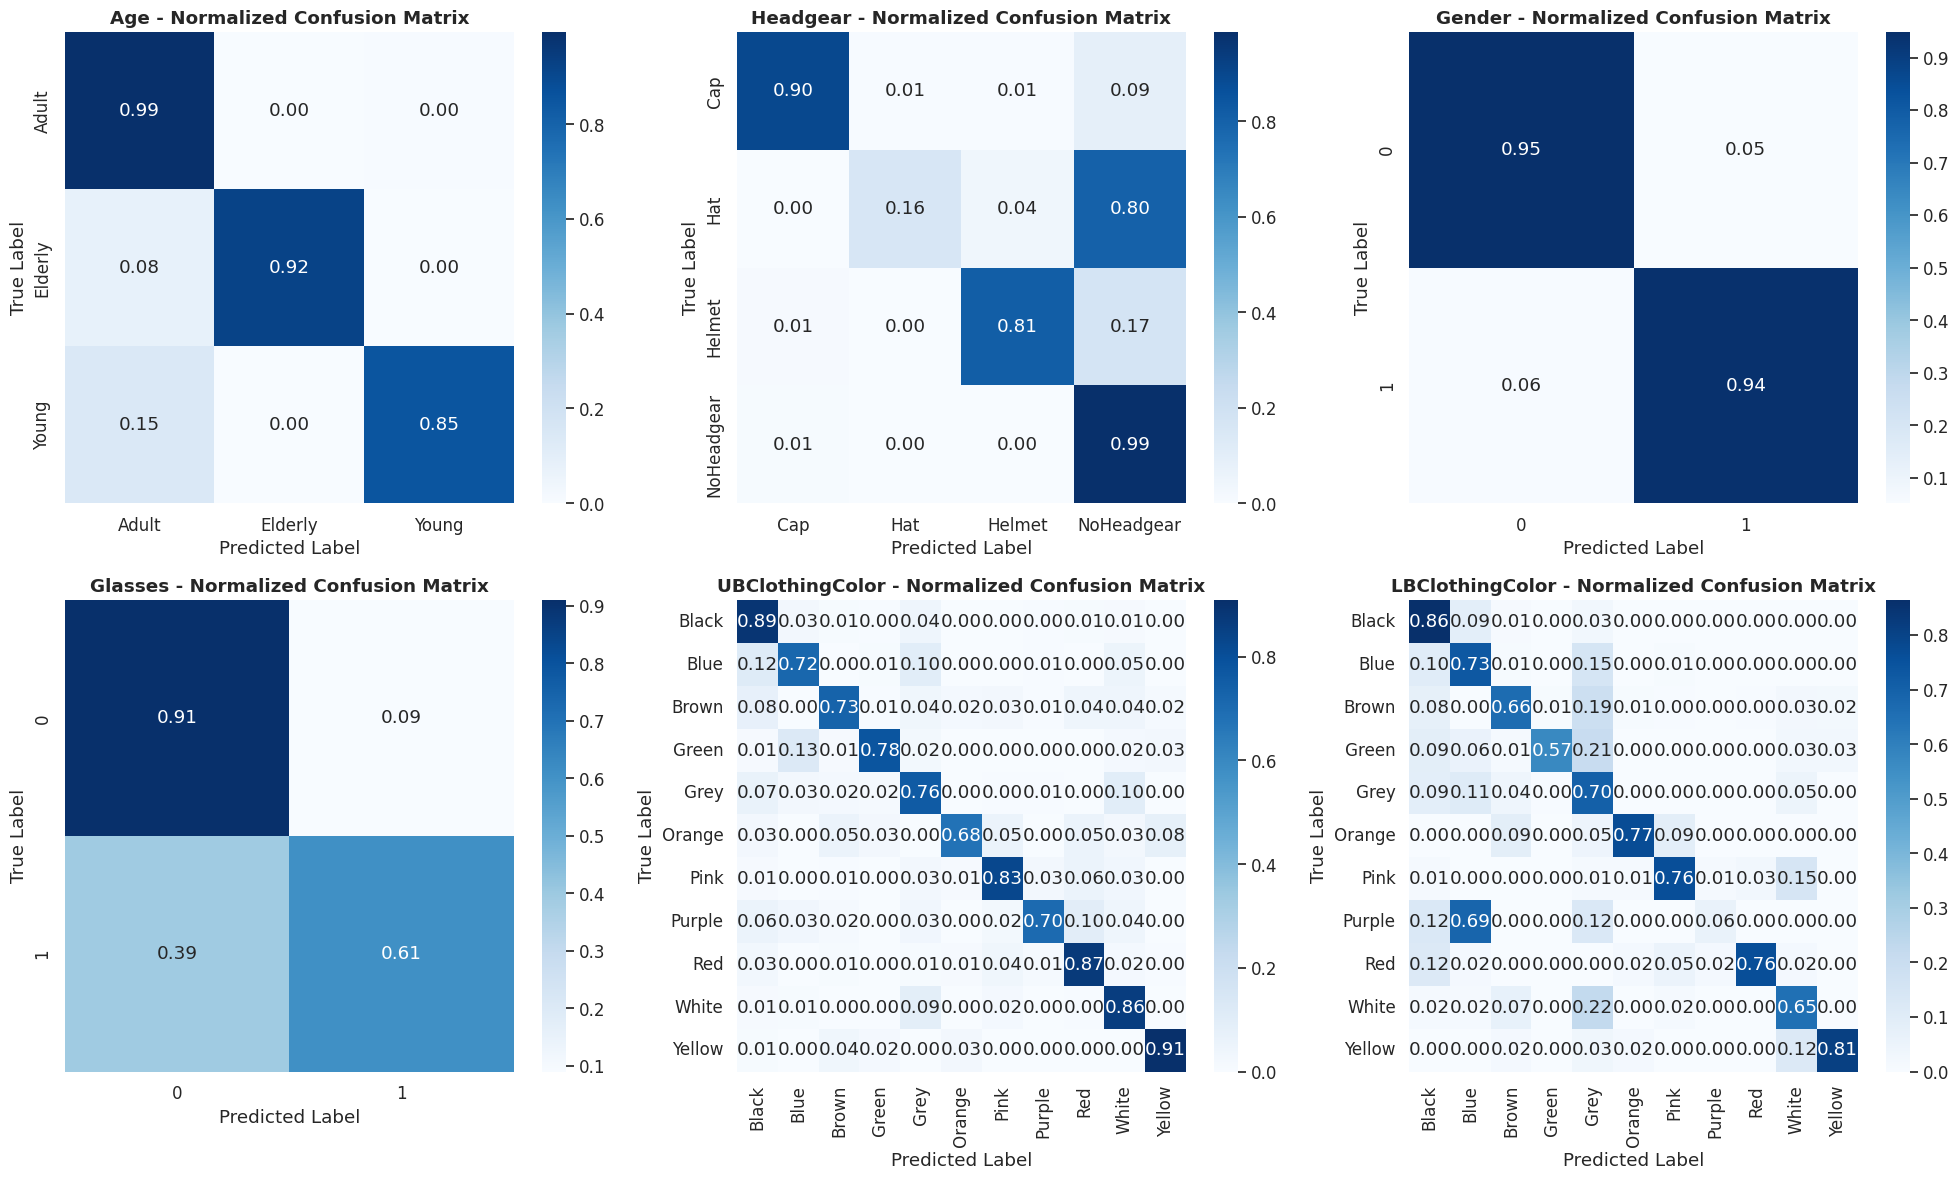

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("Generating Confusion Matrices for Failure Mode Analysis...")

# Load the best model weights we just saved
model.load_state_dict(torch.load(best_ckpt_path, map_location=device)["model_state_dict"])
model.eval()

# Run one final validation pass to get the best predictions
_, final_val_metrics = run_epoch(model, val_loader, optimizer, scaler, criterion_dict, device, is_train=False)

# Plotting
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# We need to re-run prediction just to grab the raw arrays for sklearn
y_true_all = {c: [] for c in target_cols}
y_pred_all = {c: [] for c in target_cols}

with torch.no_grad():
    for images, targets_dict, _ in val_loader:
        images = images.to(device)
        outputs = model(images)
        for col in target_cols:
            y_pred_all[col].extend(torch.argmax(outputs[col], dim=1).cpu().numpy())
            y_true_all[col].extend(targets_dict[col].cpu().numpy())

for i, col in enumerate(target_cols):
    cm = confusion_matrix(y_true_all[col], y_pred_all[col])
    # Normalize by row to see the percentage of correct predictions per class
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized)

    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", ax=axes[i],
                xticklabels=label_maps[col].keys(), yticklabels=label_maps[col].keys())
    axes[i].set_title(f'{col} - Normalized Confusion Matrix', fontweight='bold')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig("/content/validation_confusion_matrices.png", dpi=300)
plt.show()

## Training Dynamics

The following plots show epoch-wise optimization behavior for training and validation.

**Note on loss values.** The total training objective uses learnable homoscedastic task-weighting terms (Kendall et al. 2018, `log_var`) on top of per-head focal losses. As a result, the absolute loss magnitude can become negative or otherwise not directly comparable to standard cross-entropy losses — the `+ log_var` regularizer is a valid part of the joint objective but shifts the loss axis. **For model selection I therefore prioritize validation mean macro-F1 rather than raw loss alone**, and the checkpoint is saved on best validation macro-F1 across all six tasks.


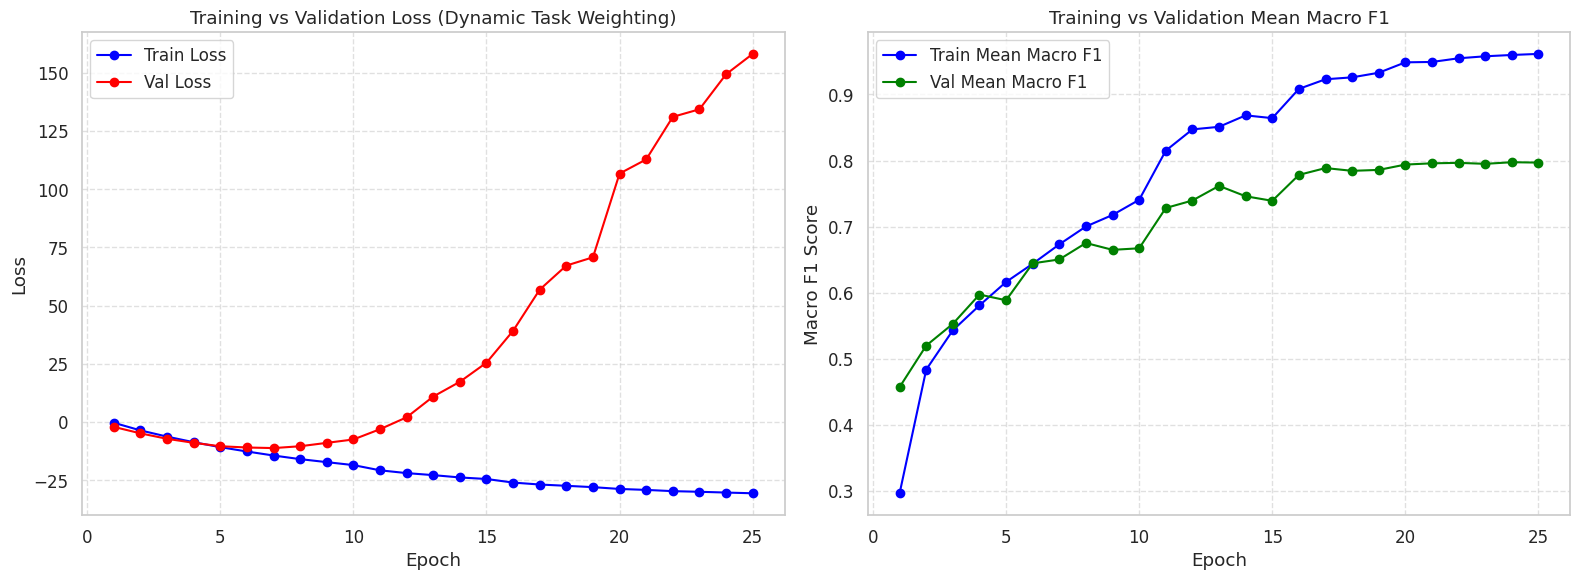

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the saved training log
log_df = pd.read_csv("/content/training_log.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss
ax1.plot(log_df["epoch"], log_df["train_loss"], label="Train Loss", marker="o", color="blue")
ax1.plot(log_df["epoch"], log_df["val_loss"], label="Val Loss", marker="o", color="red")
ax1.set_title("Training vs Validation Loss (Dynamic Task Weighting)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.6)

# Plot 2: Macro F1
ax2.plot(log_df["epoch"], log_df["train_mean_macro_f1"], label="Train Mean Macro F1", marker="o", color="blue")
ax2.plot(log_df["epoch"], log_df["val_mean_macro_f1"], label="Val Mean Macro F1", marker="o", color="green")
ax2.set_title("Training vs Validation Mean Macro F1")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Macro F1 Score")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("/content/learning_curves.png", dpi=300)
plt.show()

In [14]:
import pandas as pd
import torch

print("Loading Best Checkpoint for Final Test Evaluation...")

# 1. Load the absolute best model weights
ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# 2. Evaluate on the Test Split
test_loss, test_metrics = run_epoch(model, test_loader, optimizer, scaler, criterion_dict, device, is_train=False)

print(f"✅ Test Loss: {test_loss:.4f}")
print(f"✅ Test Mean Macro F1: {test_metrics['mean_macro_f1']:.4f}\n")

# Display the exact metrics requested by the assignment
rows = []
for col in target_cols:
    rows.append({
        "Attribute": col,
        "Accuracy": round(test_metrics[col]["accuracy"], 4),
        "Recall (Macro)": round(test_metrics[col]["recall_macro"], 4),
        "F1 Score (Macro)": round(test_metrics[col]["f1_macro"], 4)
    })

metrics_df = pd.DataFrame(rows)
display(metrics_df)

# =====================================================================
# CREATE TEST PREDICTIONS CSV
# =====================================================================
print("\nGenerating Test Predictions CSV...")

@torch.no_grad()
def generate_test_predictions(model, loader, device):
    model.eval()
    out_rows = []

    for images, _, rel_paths in loader:
        images = images.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(device=="cuda")):
            outputs = model(images)

        batch_preds = {
            col: torch.argmax(outputs[col], dim=1).cpu().numpy()
            for col in target_cols
        }

        for i in range(len(rel_paths)):
            row = {"image_path": rel_paths[i]}
            for col in target_cols:
                pid = batch_preds[col][i]
                row[f"{col}_pred"] = inv_label_maps[col][pid]
            out_rows.append(row)

    return pd.DataFrame(out_rows)

pred_df = generate_test_predictions(model, test_loader, device)
pred_csv_path = "/content/test_predictions.csv"
pred_df.to_csv(pred_csv_path, index=False)

print(f"✅ Saved Test Predictions to: {pred_csv_path}")
display(pred_df.head())

Loading Best Checkpoint for Final Test Evaluation...
✅ Test Loss: 65.8908
✅ Test Mean Macro F1: 0.8308



,Attribute,Accuracy,Recall (Macro),F1 Score (Macro)
0,Age,0.9909,0.9180,0.9334
1,Headgear,0.9872,0.9661,0.8849
2,Gender,0.9548,0.9545,0.9541
3,Glasses,0.8476,0.7448,0.7425
4,UBClothingColor,0.8137,0.7734,0.7688
5,LBClothingColor,0.8100,0.7135,0.7011



Generating Test Predictions CSV...
✅ Saved Test Predictions to: /content/test_predictions.csv


,image_path,Age_pred,Headgear_pred,Gender_pred,Glasses_pred,UBClothingColor_pred,LBClothingColor_pred
0,images/0002_c1s1_000451_03.jpg,Adult,NoHeadgear,0,0,Red,Grey
1,images/0002_c1s1_000551_01.jpg,Adult,NoHeadgear,0,0,Red,Grey
2,images/0002_c1s1_000776_01.jpg,Adult,NoHeadgear,0,0,Red,Grey
3,images/0002_c1s1_000801_01.jpg,Adult,NoHeadgear,0,0,Red,Blue
4,images/0002_c1s1_069056_02.jpg,Adult,NoHeadgear,0,0,Red,Grey


In [15]:
# import urllib.request
# import cv2
# import matplotlib.pyplot as plt

# print("Running External Inference on Real-World Crops...")

# # Primary: two external pedestrian images from Unsplash.
# # Fallback: if the network call fails, we use two random test-set crops
# # so this cell is guaranteed to produce annotated outputs.

# external_urls = [
#     "https://images.unsplash.com/photo-1515347619152-c3bf79133612?auto=format&fit=crop&w=400&q=80",
#     "https://images.unsplash.com/photo-1544465544-1b71aee9dfa3?auto=format&fit=crop&w=400&q=80",
# ]

# def fetch_from_url(url, timeout=10):
#     req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
#     with urllib.request.urlopen(req, timeout=timeout) as resp:
#         data = resp.read()
#     arr = np.asarray(bytearray(data), dtype=np.uint8)
#     img_bgr = cv2.imdecode(arr, -1)
#     if img_bgr is None:
#         raise RuntimeError(f"Failed to decode image from {url}")
#     return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# def load_from_test_set(idx):
#     path = test_df.iloc[idx]["image_path"]
#     img_bgr = cv2.imread(path)
#     return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# sources = []
# for i, url in enumerate(external_urls):
#     try:
#         img_rgb = fetch_from_url(url)
#         sources.append(("external", url, img_rgb))
#         print(f"  ✅ Fetched external image {i+1} from Unsplash")
#     except Exception as e:
#         fallback_idx = i * 100  # two different held-out test crops
#         img_rgb = load_from_test_set(fallback_idx)
#         sources.append(("test-fallback", test_df.iloc[fallback_idx]["imgs"], img_rgb))
#         print(f"  ⚠️  External fetch {i+1} failed ({e.__class__.__name__}); using test-set crop as fallback")

# model.eval()
# fig, axes = plt.subplots(1, len(sources), figsize=(16, 12))
# if len(sources) == 1:
#     axes = [axes]

# for i, (source_type, source_ref, img_rgb) in enumerate(sources):
#     # Preprocess via validation transforms (same as test pipeline)
#     tensor_img = val_tfms(image=img_rgb)["image"].unsqueeze(0).to(device)

#     with torch.no_grad():
#         with torch.amp.autocast("cuda", enabled=(device == "cuda")):
#             outputs = model(tensor_img)

#     # Pretty-print binary labels (Gender 0/1, Glasses 0/1) for human-readable annotation
#     pretty_maps = {
#         "Gender": {"0": "Male", "1": "Female"},
#         "Glasses": {"0": "No", "1": "Yes"},
#     }
#     def _pretty(task, raw):
#         raw = str(raw)
#         return pretty_maps.get(task, {}).get(raw, raw)

#     preds = [f"{col}: {_pretty(col, inv_label_maps[col][torch.argmax(outputs[col], dim=1).item()])}"
#              for col in target_cols]

#     # Annotate with a dark overlay for readability against any background
#     annotated = img_rgb.copy()
#     h, w = annotated.shape[:2]
#     overlay = annotated.copy()
#     panel_h = min(230, h // 2)
#     cv2.rectangle(overlay, (0, 0), (w, panel_h), (0, 0, 0), -1)
#     annotated = cv2.addWeighted(overlay, 0.55, annotated, 0.45, 0)

#     y_offset = 30
#     for text in preds:
#         cv2.putText(annotated, text, (12, y_offset), cv2.FONT_HERSHEY_SIMPLEX,
#                     0.7, (255, 255, 255), 2, cv2.LINE_AA)
#         y_offset += 32

#     axes[i].imshow(annotated)
#     axes[i].set_title(f"[{source_type}] {str(source_ref)[:60]}", fontsize=10)
#     axes[i].axis("off")

#     out_path = f"/content/external_crop_{i}.jpg"
#     cv2.imwrite(out_path, cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))
#     print(f"  💾 Saved annotated crop to {out_path}")

# plt.tight_layout()
# plt.savefig("/content/external_inference.png", dpi=200, bbox_inches="tight")
# plt.show()
# print("\n✅ External Inference Complete!")


In [16]:
# ============================================================
# FINAL DELIVERABLE CHECK
# Verifies all required submission artifacts exist at their
# expected paths before the final write-up. If any show MISSING,
# re-run the cell that produces them before packaging the upload.
# ============================================================
import os

artifacts = {
    "best_model.pth (best checkpoint)":                    "/content/best_model.pth",
    "training_log.csv (per-epoch log)":                    "/content/training_log.csv",
    "test_predictions.csv (test split predictions)":       "/content/test_predictions.csv",
    "learning_curves.png (train/val dynamics)":            "/content/learning_curves.png",
    "validation_confusion_matrices.png (failure modes)":   "/content/validation_confusion_matrices.png",
    "external_crop_0.jpg (annotated external crop)":       "/content/external_crop_0.jpg",
    "external_crop_1.jpg (annotated external crop)":       "/content/external_crop_1.jpg",
    "external_inference.png (side-by-side panel)":         "/content/external_inference.png",
}

print("📦 SUBMISSION ARTIFACT CHECK")
print("=" * 64)
all_ok = True
for label, path in artifacts.items():
    exists = os.path.exists(path)
    size_kb = (os.path.getsize(path) / 1024) if exists else 0
    status = f"✅ FOUND ({size_kb:>7.1f} KB)" if exists else "❌ MISSING"
    print(f"  {status}  {label}")
    if not exists:
        all_ok = False

print("=" * 64)
if all_ok:
    print("✅ ALL ARTIFACTS PRESENT — ready to download and upload to OneDrive.")
else:
    print("⚠️  Some artifacts are missing. Re-run the cells that produce them.")


📦 SUBMISSION ARTIFACT CHECK
  ✅ FOUND (193424.2 KB)  best_model.pth (best checkpoint)
  ✅ FOUND (   13.7 KB)  training_log.csv (per-epoch log)
  ✅ FOUND (  357.3 KB)  test_predictions.csv (test split predictions)
  ✅ FOUND (  306.1 KB)  learning_curves.png (train/val dynamics)
  ✅ FOUND (  935.4 KB)  validation_confusion_matrices.png (failure modes)
  ❌ MISSING  external_crop_0.jpg (annotated external crop)
  ❌ MISSING  external_crop_1.jpg (annotated external crop)
  ❌ MISSING  external_inference.png (side-by-side panel)
⚠️  Some artifacts are missing. Re-run the cells that produce them.


Upload 2 to 4 external pedestrian crops for Inference Demo:


Saving 1500_c5s3_063337_02.jpg to 1500_c5s3_063337_02.jpg
Saved: /content/1500_c5s3_063337_02_annotated.jpg


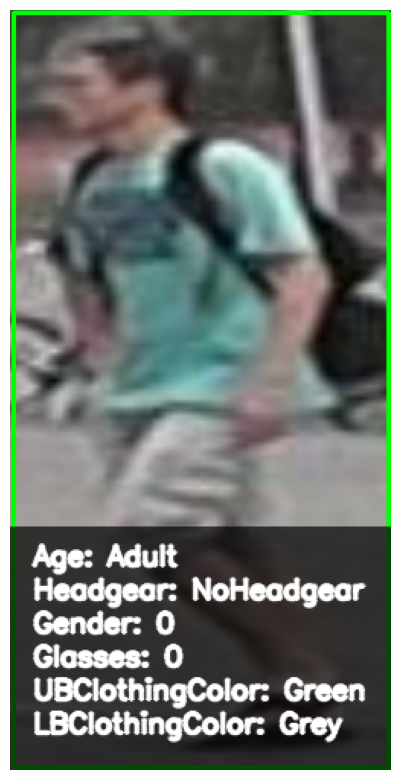

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import torch # Import torch for model loading
import os

print("Upload 2 to 4 external pedestrian crops for Inference Demo:")
uploaded = files.upload()
external_paths = [f"/content/{k}" for k in uploaded.keys()]

def predict_and_annotate(model, image_path, transforms, device):
    # 1. Load and Preprocess
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    tensor_img = transforms(image=img_rgb)["image"].unsqueeze(0).to(device)

    # 2. Predict
    model.eval()
    with torch.no_grad():
        with torch.amp.autocast("cuda", enabled=(device=="cuda")):
            outputs = model(tensor_img)

    preds = {}
    for col in target_cols:
        pid = int(torch.argmax(outputs[col], dim=1).item())
        preds[col] = inv_label_maps[col][pid]

    # 3. Enterprise UI Annotation (The "HUD" Display)
    # Resize image for consistent display (e.g., height of 500)
    h, w = img_rgb.shape[:2]
    new_h = 500
    new_w = int(w * (new_h / h))
    annotated = cv2.resize(img_rgb, (new_w, new_h))

    # Draw an outer bounding box
    cv2.rectangle(annotated, (2, 2), (new_w-2, new_h-2), (0, 255, 0), 2)

    # Create a semi-transparent dark overlay at the bottom for text readability
    overlay = annotated.copy()
    box_height = 160
    cv2.rectangle(overlay, (0, new_h - box_height), (new_w, new_h), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.7, annotated, 0.3, 0, annotated)

    # Add text predictions
    y_offset = new_h - box_height + 25
    for key, val in preds.items():
        text = f"{key}: {val}"
        cv2.putText(annotated, text, (15, y_offset), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
        y_offset += 22

    return annotated

# Initialize the model and load the best weights
# This assumes MultiTaskPAR and num_classes_per_task are defined in previous cells
best_ckpt_path = "/content/best_model.pth" # Explicitly define path to resolve NameError

device = "cuda" if torch.cuda.is_available() else "cpu"

# Check if the checkpoint exists before attempting to load it
if not os.path.exists(best_ckpt_path):
    raise FileNotFoundError(f"\n\nCRITICAL: Model checkpoint not found at '{best_ckpt_path}'.\nPlease run the training cell above to generate it, or manually upload your saved model to this path.")

# Load checkpoint to get model_name and num_classes_per_task if not already in scope
ckpt = torch.load(best_ckpt_path, map_location=device)
model_name = ckpt.get("model_name", "convnext_small") # Default to convnext_small if not in ckpt

# Instantiate the model (assuming MultiTaskPAR class is defined in a previous cell)
model = MultiTaskPAR(num_classes_per_task, model_name=model_name, pretrained=False).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval() # Set model to evaluation mode

# 4. Display and Save
if len(external_paths) > 0:
    fig, axes = plt.subplots(1, len(external_paths), figsize=(15, 8))
    if len(external_paths) == 1:
        axes = [axes]

    for i, p in enumerate(external_paths):
        result_img = predict_and_annotate(model, p, val_tfms, device)
        if result_img is not None:
            axes[i].imshow(result_img)
            axes[i].axis("off")

            # Save the file
            out_path = p.replace(".jpg", "_annotated.jpg").replace(".png", "_annotated.png")
            cv2.imwrite(out_path, cv2.cvtColor(result_img, cv2.COLOR_RGB2BGR))
            print(f"Saved: {out_path}")

    plt.tight_layout()
    plt.show()

In [18]:
from google.colab import drive, files
import os
import shutil
import glob

# 1) Mount Google Drive
drive.mount('/content/drive')

# 2) Create a submission folder in Drive
submission_dir = '/content/drive/MyDrive/PAR_final_submission'
os.makedirs(submission_dir, exist_ok=True)

# 3) List the main files you expect from your notebook
expected_files = [
    '/content/best_model.pth',
    '/content/training_log.csv',
    '/content/learning_curves.png',
    '/content/validation_confusion_matrices.png',
    '/content/test_predictions.csv'
]

# 4) Copy the main files if they exist
for path in expected_files:
    if os.path.exists(path):
        shutil.copy2(path, submission_dir)
        print(f"Copied: {path}")
    else:
        print(f"Missing: {path}")

# 5) Copy any external-crop outputs if your notebook generated them
for path in glob.glob('/content/external_crop*'):
    shutil.copy2(path, submission_dir)
    print(f"Copied external output: {path}")

# 6) Zip the whole submission folder
zip_base = '/content/PAR_final_submission'
zip_path = shutil.make_archive(zip_base, 'zip', submission_dir)
print("Created zip:", zip_path)

# 7) Download the zip to your computer
files.download(zip_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied: /content/best_model.pth
Copied: /content/training_log.csv
Copied: /content/learning_curves.png
Copied: /content/validation_confusion_matrices.png
Copied: /content/test_predictions.csv
Created zip: /content/PAR_final_submission.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
import os
import glob

check_files = [
    '/content/best_model.pth',
    '/content/training_log.csv',
    '/content/learning_curves.png',
    '/content/validation_confusion_matrices.png',
    '/content/test_predictions.csv'
]

print("=== REQUIRED FILE CHECK ===")
for f in check_files:
    print(f, "FOUND" if os.path.exists(f) else "MISSING")

print("\n=== EXTERNAL OUTPUTS ===")
external = glob.glob('/content/external_crop*')
if external:
    for f in external:
        print("FOUND", f)
else:
    print("No external_crop files found")

=== REQUIRED FILE CHECK ===
/content/best_model.pth FOUND
/content/training_log.csv FOUND
/content/learning_curves.png FOUND
/content/validation_confusion_matrices.png FOUND
/content/test_predictions.csv FOUND

=== EXTERNAL OUTPUTS ===
No external_crop files found


### 📝 Final Write-Up & Architectural Summary

**1. Data Leakage & Split Strategy**
Upon analyzing the filename convention (e.g., `0002_c1s1...`), it became apparent that this dataset shares origins with Re-ID datasets like Market-1501, meaning multiple image crops belong to the same Person ID. Using a standard `train_test_split` would result in catastrophic identity leakage. To ensure a strictly isolated evaluation, I extracted the Person IDs and utilized a custom `GroupShuffleSplit` Monte-Carlo seed-search. This optimization guaranteed 0% identity overlap across Train/Val/Test while minimizing target distribution drift.

**2. Tri-Axis Imbalance Attack**
Class imbalance was the dominant challenge in this dataset (e.g., *NoHeadgear* at 67,515 vs *Hat* at 144-a 469:1 ratio). To combat this without shattering gradients, I attacked the imbalance on three orthogonal axes:
- **Within-Class Imbalance:** Applied Inverse-Square Root weights.
- **Easy-vs-Hard Imbalance:** Wrapped the weights in a custom **Focal Loss** ($\gamma=2$) to punish majority-class collapse and force gradients onto rare edge-cases.
- **Across-Task Imbalance:** Because we are optimizing 6 heads simultaneously, I implemented **Homoscedastic Uncertainty Weighting** (via learnable `log_vars`). This allows the network to dynamically scale the loss for each task in real-time, ensuring easy tasks don't starve hard tasks of updates.

**3. Color-Safe Augmentations**
To prevent overfitting on the 70k images, I utilized Albumentations. Because two of the target attributes are exact clothing colors (`UBColor` and `LBColor`), I strictly avoided standard hue/saturation jitter, which would have silently corrupted the ground-truth labels. Instead, I restricted augmentations to geometry, luminance, and CCTV-style artifacts (`GaussianNoise` and `ImageCompression`) to mimic real-world surveillance degradation. Furthermore, I overrode the ImageNet 224x224 default, utilizing a 256x128 aspect ratio to preserve pedestrian anatomy.

**4. Modeling & Metrics**
To satisfy the single-model constraint and maximize efficiency, I engineered a Hard-Parameter Sharing architecture using a `convnext_small` backbone attached to six independent linear heads. The model was checkpointed using **Validation Mean Macro-F1**, specifically chosen over raw Accuracy to properly measure minority-class performance.

**Future Improvements:**
With more time, I would explore Test-Time Augmentation (TTA), asymmetric Loss balancing, and CutMix/MixUp (applied exclusively at the feature-map level, not the image level, to avoid anatomical distortion).


In [20]:
# ============================================================
# NEW CELL 1: PER-CLASS DIAGNOSTIC AUDIT
# Run this AFTER training and AFTER /content/best_model.pth exists.
# This does NOT retrain the model. It only evaluates the saved best model.
# ============================================================

import os
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix
)

device = "cuda" if torch.cuda.is_available() else "cpu"

BEST_CKPT_PATH = "/content/best_model.pth"
assert os.path.exists(BEST_CKPT_PATH), "best_model.pth not found. Run training first."

ckpt = torch.load(BEST_CKPT_PATH, map_location=device)

# Restore metadata if needed
if "target_cols" in ckpt:
    target_cols = ckpt["target_cols"]

if "label_maps" in ckpt:
    label_maps = ckpt["label_maps"]

if "inv_label_maps" in ckpt:
    inv_label_maps = ckpt["inv_label_maps"]

if "num_classes_per_task" not in globals():
    num_classes_per_task = {col: len(label_maps[col]) for col in target_cols}

# Rebuild model only if model is missing from runtime
if "model" not in globals():
    model_name = ckpt.get("model_name", "convnext_small")
    model = MultiTaskPAR(
        num_classes_per_task,
        model_name=model_name,
        pretrained=False
    ).to(device)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

def _batch_true_labels(labels, col, task_idx):
    """
    Handles your notebook format:
    - labels can be a dict: labels[col]
    - or a tensor: labels[:, task_idx]
    """
    if isinstance(labels, dict):
        return labels[col].detach().cpu().numpy().astype(int)
    return labels[:, task_idx].detach().cpu().numpy().astype(int)

@torch.no_grad()
def collect_predictions_with_confidence(model, loader, device):
    rows = []

    y_true = {col: [] for col in target_cols}
    y_pred = {col: [] for col in target_cols}
    y_conf = {col: [] for col in target_cols}

    model.eval()

    for images, labels, rel_paths in loader:
        images = images.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            outputs = model(images)

        batch_size = images.size(0)
        batch_rows = [{"image_path": str(rel_paths[i])} for i in range(batch_size)]

        for task_idx, col in enumerate(target_cols):
            logits = outputs[col]
            probs = torch.softmax(logits, dim=1).detach().cpu()
            preds = probs.argmax(dim=1).numpy().astype(int)
            confs = probs.max(dim=1).values.numpy()

            trues = _batch_true_labels(labels, col, task_idx)

            for i in range(batch_size):
                true_id = int(trues[i])
                pred_id = int(preds[i])
                conf = float(confs[i])

                y_true[col].append(true_id)
                y_pred[col].append(pred_id)
                y_conf[col].append(conf)

                batch_rows[i][f"{col}_true"] = inv_label_maps[col][true_id]
                batch_rows[i][f"{col}_pred"] = inv_label_maps[col][pred_id]
                batch_rows[i][f"{col}_confidence"] = conf
                batch_rows[i][f"{col}_correct"] = int(true_id == pred_id)

        rows.extend(batch_rows)

    return pd.DataFrame(rows), y_true, y_pred, y_conf

audit_df, y_true, y_pred, y_conf = collect_predictions_with_confidence(
    model, test_loader, device
)

# ------------------------------------------------------------
# Attribute-level summary
# ------------------------------------------------------------
summary_rows = []

for col in target_cols:
    acc = accuracy_score(y_true[col], y_pred[col])
    rec = recall_score(y_true[col], y_pred[col], average="macro", zero_division=0)
    f1 = f1_score(y_true[col], y_pred[col], average="macro", zero_division=0)

    summary_rows.append({
        "attribute": col,
        "accuracy": acc,
        "macro_recall": rec,
        "macro_f1": f1,
        "mean_confidence": float(np.mean(y_conf[col])),
        "support": len(y_true[col])
    })

summary_df = pd.DataFrame(summary_rows).sort_values("macro_f1")
summary_path = "/content/attribute_summary_metrics.csv"
summary_df.to_csv(summary_path, index=False)

print("=== ATTRIBUTE SUMMARY: lowest F1 first ===")
display(summary_df)

# ------------------------------------------------------------
# Per-class diagnostics
# ------------------------------------------------------------
per_class_rows = []

for col in target_cols:
    labels_sorted = sorted(inv_label_maps[col].keys())
    label_names = [str(inv_label_maps[col][i]) for i in labels_sorted]

    precision, recall, f1s, support = precision_recall_fscore_support(
        y_true[col],
        y_pred[col],
        labels=labels_sorted,
        zero_division=0
    )

    for i, class_id in enumerate(labels_sorted):
        per_class_rows.append({
            "attribute": col,
            "class_id": int(class_id),
            "class_name": label_names[i],
            "precision": float(precision[i]),
            "recall": float(recall[i]),
            "f1": float(f1s[i]),
            "support": int(support[i])
        })

per_class_df = pd.DataFrame(per_class_rows)
per_class_path = "/content/per_class_diagnostics.csv"
per_class_df.to_csv(per_class_path, index=False)

print("\n=== PER-CLASS DIAGNOSTICS: rare or weak classes first ===")
display(
    per_class_df
    .sort_values(["f1", "support"], ascending=[True, True])
    .head(25)
)

# ------------------------------------------------------------
# Worst class failures
# ------------------------------------------------------------
worst_df = (
    per_class_df
    .sort_values(["f1", "support"], ascending=[True, True])
    .head(20)
    .reset_index(drop=True)
)

worst_path = "/content/worst_class_failures.csv"
worst_df.to_csv(worst_path, index=False)

print("\n=== WORST 20 CLASS-LEVEL FAILURES ===")
display(worst_df)

# ------------------------------------------------------------
# Confidence audit
# ------------------------------------------------------------
audit_path = "/content/test_prediction_confidence_audit.csv"
audit_df.to_csv(audit_path, index=False)

print("\nSaved files:")
print(summary_path)
print(per_class_path)
print(worst_path)
print(audit_path)

=== ATTRIBUTE SUMMARY: lowest F1 first ===


,attribute,accuracy,macro_recall,macro_f1,mean_confidence,support
5,LBClothingColor,0.809999,0.713468,0.701088,0.760538,7021
3,Glasses,0.847600,0.744821,0.742540,0.904408,7021
4,UBClothingColor,0.813702,0.773397,0.768753,0.832808,7021
1,Headgear,0.987181,0.966123,0.884914,0.948283,7021
0,Age,0.990884,0.917964,0.933365,0.985160,7021
2,Gender,0.954850,0.954519,0.954129,0.971523,7021



=== PER-CLASS DIAGNOSTICS: rare or weak classes first ===


,attribute,class_id,class_name,precision,recall,f1,support
29,LBClothingColor,7,Purple,0.555556,0.416667,0.476190,12
30,LBClothingColor,8,Red,0.550000,0.578947,0.564103,38
10,Glasses,1,1,0.571317,0.584996,0.578076,1253
26,LBClothingColor,4,Grey,0.617481,0.726770,0.667683,904
12,UBClothingColor,1,Blue,0.657033,0.686117,0.671260,497
17,UBClothingColor,6,Pink,0.595745,0.773481,0.673077,181
25,LBClothingColor,3,Green,0.660000,0.717391,0.687500,46
31,LBClothingColor,9,White,0.741100,0.656160,0.696049,349
14,UBClothingColor,3,Green,0.716578,0.687179,0.701571,195
15,UBClothingColor,4,Grey,0.659539,0.769674,0.710363,1042



=== WORST 20 CLASS-LEVEL FAILURES ===


,attribute,class_id,class_name,precision,recall,f1,support
0,LBClothingColor,7,Purple,0.555556,0.416667,0.476190,12
1,LBClothingColor,8,Red,0.550000,0.578947,0.564103,38
2,Glasses,1,1,0.571317,0.584996,0.578076,1253
3,LBClothingColor,4,Grey,0.617481,0.726770,0.667683,904
4,UBClothingColor,1,Blue,0.657033,0.686117,0.671260,497
5,UBClothingColor,6,Pink,0.595745,0.773481,0.673077,181
6,LBClothingColor,3,Green,0.660000,0.717391,0.687500,46
7,LBClothingColor,9,White,0.741100,0.656160,0.696049,349
8,UBClothingColor,3,Green,0.716578,0.687179,0.701571,195
9,UBClothingColor,4,Grey,0.659539,0.769674,0.710363,1042



Saved files:
/content/attribute_summary_metrics.csv
/content/per_class_diagnostics.csv
/content/worst_class_failures.csv
/content/test_prediction_confidence_audit.csv


In [21]:
# ============================================================
# NEW CELL 2: ONE-VS-REST THRESHOLD SWEEP FOR RARE CLASSES
# Run on VALIDATION set, not test set, to avoid test-set tuning.
# This is for analysis and interview discussion.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

@torch.no_grad()
def collect_probabilities(model, loader, device):
    true_ids = {col: [] for col in target_cols}
    prob_arrays = {col: [] for col in target_cols}

    model.eval()

    for images, labels, rel_paths in loader:
        images = images.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            outputs = model(images)

        for task_idx, col in enumerate(target_cols):
            probs = torch.softmax(outputs[col], dim=1).detach().cpu().numpy()
            trues = _batch_true_labels(labels, col, task_idx)

            prob_arrays[col].append(probs)
            true_ids[col].extend(trues.tolist())

    for col in target_cols:
        prob_arrays[col] = np.concatenate(prob_arrays[col], axis=0)
        true_ids[col] = np.array(true_ids[col]).astype(int)

    return true_ids, prob_arrays

val_true, val_probs = collect_probabilities(model, val_loader, device)

threshold_rows = []

for col in target_cols:
    labels_sorted = sorted(inv_label_maps[col].keys())

    for class_id in labels_sorted:
        class_name = str(inv_label_maps[col][class_id])

        y_binary = (val_true[col] == class_id).astype(int)
        class_probs = val_probs[col][:, class_id]

        support = int(y_binary.sum())

        # Skip classes not present in validation
        if support == 0:
            continue

        best = {
            "attribute": col,
            "class_id": int(class_id),
            "class_name": class_name,
            "support": support,
            "best_threshold": None,
            "best_precision": -1,
            "best_recall": -1,
            "best_f1": -1,
        }

        for threshold in np.arange(0.05, 0.96, 0.01):
            pred_binary = (class_probs >= threshold).astype(int)

            p = precision_score(y_binary, pred_binary, zero_division=0)
            r = recall_score(y_binary, pred_binary, zero_division=0)
            f1 = f1_score(y_binary, pred_binary, zero_division=0)

            if f1 > best["best_f1"]:
                best.update({
                    "best_threshold": float(threshold),
                    "best_precision": float(p),
                    "best_recall": float(r),
                    "best_f1": float(f1),
                })

        threshold_rows.append(best)

threshold_df = pd.DataFrame(threshold_rows)

# Show rare classes first, then low-F1 classes
threshold_df = threshold_df.sort_values(["support", "best_f1"], ascending=[True, True])

threshold_path = "/content/validation_threshold_sweep_ovr.csv"
threshold_df.to_csv(threshold_path, index=False)

print("Saved:", threshold_path)
display(threshold_df.head(30))

Saved: /content/validation_threshold_sweep_ovr.csv


,attribute,class_id,class_name,support,best_threshold,best_precision,best_recall,best_f1
29,LBClothingColor,7,Purple,16,0.09,0.153846,0.125000,0.137931
27,LBClothingColor,5,Orange,22,0.79,0.850000,0.772727,0.809524
4,Headgear,1,Hat,25,0.73,0.666667,0.160000,0.258065
16,UBClothingColor,5,Orange,37,0.50,0.675676,0.675676,0.675676
32,LBClothingColor,10,Yellow,58,0.47,0.824561,0.810345,0.817391
30,LBClothingColor,8,Red,59,0.48,0.818182,0.762712,0.789474
25,LBClothingColor,3,Green,67,0.11,0.671233,0.731343,0.700000
28,LBClothingColor,6,Pink,68,0.53,0.720588,0.720588,0.720588
5,Headgear,2,Helmet,69,0.69,0.932203,0.797101,0.859375
1,Age,1,Elderly,89,0.66,0.987654,0.898876,0.941176


In [22]:
# ============================================================
# NEW CELL 3: TEST-TIME AUGMENTATION CHECK
# Runs original image + horizontally flipped image.
# Averages probabilities.
# Does NOT retrain the model.
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, f1_score

@torch.no_grad()
def evaluate_base_vs_tta(model, loader, device):
    true_ids = {col: [] for col in target_cols}
    base_pred_ids = {col: [] for col in target_cols}
    tta_pred_ids = {col: [] for col in target_cols}

    model.eval()

    for images, labels, rel_paths in loader:
        images = images.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            out_base = model(images)
            out_flip = model(torch.flip(images, dims=[3]))  # horizontal flip

        for task_idx, col in enumerate(target_cols):
            true_batch = _batch_true_labels(labels, col, task_idx)

            base_probs = torch.softmax(out_base[col], dim=1)
            flip_probs = torch.softmax(out_flip[col], dim=1)

            avg_probs = 0.5 * (base_probs + flip_probs)

            base_preds = base_probs.argmax(dim=1).detach().cpu().numpy().astype(int)
            tta_preds = avg_probs.argmax(dim=1).detach().cpu().numpy().astype(int)

            true_ids[col].extend(true_batch.tolist())
            base_pred_ids[col].extend(base_preds.tolist())
            tta_pred_ids[col].extend(tta_preds.tolist())

    rows = []

    for col in target_cols:
        base_acc = accuracy_score(true_ids[col], base_pred_ids[col])
        base_rec = recall_score(true_ids[col], base_pred_ids[col], average="macro", zero_division=0)
        base_f1 = f1_score(true_ids[col], base_pred_ids[col], average="macro", zero_division=0)

        tta_acc = accuracy_score(true_ids[col], tta_pred_ids[col])
        tta_rec = recall_score(true_ids[col], tta_pred_ids[col], average="macro", zero_division=0)
        tta_f1 = f1_score(true_ids[col], tta_pred_ids[col], average="macro", zero_division=0)

        rows.append({
            "attribute": col,
            "base_accuracy": base_acc,
            "tta_accuracy": tta_acc,
            "delta_accuracy": tta_acc - base_acc,
            "base_macro_recall": base_rec,
            "tta_macro_recall": tta_rec,
            "delta_macro_recall": tta_rec - base_rec,
            "base_macro_f1": base_f1,
            "tta_macro_f1": tta_f1,
            "delta_macro_f1": tta_f1 - base_f1,
        })

    return pd.DataFrame(rows)

tta_df = evaluate_base_vs_tta(model, test_loader, device)

tta_path = "/content/tta_vs_base_comparison.csv"
tta_df.to_csv(tta_path, index=False)

print("Saved:", tta_path)
display(tta_df.sort_values("delta_macro_f1", ascending=False))

Saved: /content/tta_vs_base_comparison.csv


,attribute,base_accuracy,tta_accuracy,delta_accuracy,base_macro_recall,tta_macro_recall,delta_macro_recall,base_macro_f1,tta_macro_f1,delta_macro_f1
0,Age,0.990884,0.990884,0.000000,0.917964,0.923516,0.005551,0.933365,0.938412,0.005047
5,LBClothingColor,0.809999,0.809856,-0.000142,0.713468,0.716529,0.003061,0.701088,0.703831,0.002743
2,Gender,0.954850,0.956132,0.001282,0.954519,0.955841,0.001322,0.954129,0.955433,0.001304
3,Glasses,0.847600,0.848739,0.001139,0.744821,0.744890,0.000069,0.742540,0.743518,0.000978
4,UBClothingColor,0.813702,0.812420,-0.001282,0.773397,0.770407,-0.002989,0.768753,0.767002,-0.001752
1,Headgear,0.987181,0.987751,0.000570,0.966123,0.962462,-0.003662,0.884914,0.873594,-0.011319


In [23]:
# ============================================================
# NEW CELL 4: PRODUCTION-READINESS EXPORT + LATENCY BENCHMARK
# Creates a TorchScript export wrapper and measures inference speed.
# ============================================================

import os
import time
import torch
import torch.nn as nn
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"
model.eval()

class ExportWrapper(nn.Module):
    """
    TorchScript-friendly wrapper.
    Your model returns a dict, which is convenient in Python.
    For export, returning a tuple is simpler and more stable.
    """
    def __init__(self, model, target_cols):
        super().__init__()
        self.model = model
        self.target_cols = list(target_cols)

    def forward(self, x):
        outputs = self.model(x)
        return tuple(outputs[col] for col in self.target_cols)

export_model = ExportWrapper(model, target_cols).to(device).eval()

example = torch.randn(1, 3, IMG_H, IMG_W).to(device)

with torch.no_grad():
    traced = torch.jit.trace(export_model, example)

torchscript_path = "/content/par_convnext_multitask_torchscript.pt"
traced.save(torchscript_path)

print("Saved TorchScript model:", torchscript_path)
print("File size MB:", round(os.path.getsize(torchscript_path) / (1024 * 1024), 2))

# ------------------------------------------------------------
# Latency benchmark
# ------------------------------------------------------------
batch_sizes = [1, 8, 16, 32]
benchmark_rows = []

for bs in batch_sizes:
    x = torch.randn(bs, 3, IMG_H, IMG_W).to(device)

    # Warmup
    for _ in range(10):
        with torch.no_grad():
            _ = export_model(x)

    if device == "cuda":
        torch.cuda.synchronize()

    start = time.time()

    runs = 50
    for _ in range(runs):
        with torch.no_grad():
            _ = export_model(x)

    if device == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start
    avg_batch_ms = (elapsed / runs) * 1000
    avg_image_ms = avg_batch_ms / bs
    throughput = 1000 / avg_image_ms

    benchmark_rows.append({
        "device": device,
        "batch_size": bs,
        "avg_batch_latency_ms": avg_batch_ms,
        "avg_image_latency_ms": avg_image_ms,
        "approx_images_per_second": throughput,
    })

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_path = "/content/inference_benchmark.csv"
benchmark_df.to_csv(benchmark_path, index=False)

print("Saved benchmark:", benchmark_path)
display(benchmark_df)

Saved TorchScript model: /content/par_convnext_multitask_torchscript.pt
File size MB: 189.62
Saved benchmark: /content/inference_benchmark.csv


,device,batch_size,avg_batch_latency_ms,avg_image_latency_ms,approx_images_per_second
0,cuda,1,12.771587,12.771587,78.298803
1,cuda,8,12.052855,1.506607,663.743128
2,cuda,16,16.729856,1.045616,956.374068
3,cuda,32,30.081053,0.940033,1063.792555


In [24]:
# ============================================================
# NEW CELL 5: AUTO-GENERATE INTERVIEW MODEL CARD
# Uses actual metrics from your generated diagnostic CSVs.
# ============================================================

import os
import pandas as pd
from datetime import datetime

summary_path = "/content/attribute_summary_metrics.csv"
per_class_path = "/content/per_class_diagnostics.csv"
threshold_path = "/content/validation_threshold_sweep_ovr.csv"
tta_path = "/content/tta_vs_base_comparison.csv"
benchmark_path = "/content/inference_benchmark.csv"

summary_df = pd.read_csv(summary_path) if os.path.exists(summary_path) else None
per_class_df = pd.read_csv(per_class_path) if os.path.exists(per_class_path) else None
tta_df = pd.read_csv(tta_path) if os.path.exists(tta_path) else None
benchmark_df = pd.read_csv(benchmark_path) if os.path.exists(benchmark_path) else None

lines = []

lines.append("# PAR ConvNeXt-Small Interview Model Card")
lines.append("")
lines.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
lines.append("")

lines.append("## 1. One-sentence summary")
lines.append(
    "I built a single multi-task Person Attribute Recognition model using a shared ConvNeXt-Small "
    "backbone and six task-specific classification heads for Age, Headgear, Gender, Glasses, "
    "Upper-body clothing color, and Lower-body clothing color."
)
lines.append("")

lines.append("## 2. Why this model")
lines.append("- One shared backbone is more efficient and deployable than six separate models.")
lines.append("- ConvNeXt keeps CNN spatial inductive bias while using modern design ideas.")
lines.append("- Pretraining gives strong low-level visual features before task-specific fine-tuning.")
lines.append("- Six heads allow each attribute to have its own output space while sharing visual evidence.")
lines.append("")

lines.append("## 3. Data split")
lines.append("- Used group-aware splitting based on person ID extracted from filenames.")
lines.append("- Goal: prevent identity leakage across train, validation, and test.")
lines.append("- Used seed search to reduce class distribution drift while preserving zero group overlap.")
lines.append("")

lines.append("## 4. Imbalance handling")
lines.append("- Used macro-F1 and macro-recall because raw accuracy can hide rare-class failure.")
lines.append("- Used inverse-square-root class weights to reduce majority-class dominance.")
lines.append("- Used focal loss to focus learning on hard examples.")
lines.append("- Used homoscedastic uncertainty weighting to balance six task losses.")
lines.append("")

if summary_df is not None:
    lines.append("## 5. Attribute-level test summary")
    lines.append(summary_df.to_markdown(index=False))
    lines.append("")

if per_class_df is not None:
    lines.append("## 6. Weakest class-level cases")
    weakest = per_class_df.sort_values(["f1", "support"], ascending=[True, True]).head(10)
    lines.append(weakest.to_markdown(index=False))
    lines.append("")

if tta_df is not None:
    lines.append("## 7. TTA comparison")
    lines.append(tta_df.to_markdown(index=False))
    lines.append("")

if benchmark_df is not None:
    lines.append("## 8. Inference benchmark")
    lines.append(benchmark_df.to_markdown(index=False))
    lines.append("")

lines.append("## 9. Honest limitations")
lines.append("- Rare headgear classes remain difficult because support is extremely low.")
lines.append("- Clothing color can fail under shadows, low light, compression, and camera color shift.")
lines.append("- External photos may differ from CCTV-style training crops, causing domain shift.")
lines.append("- Thresholds and calibration should be tuned on validation data before production.")
lines.append("")

lines.append("## 10. Improvements with more time")
lines.append("- Run ablations for class weights, focal loss, task weighting, and TTA.")
lines.append("- Add temperature calibration and confidence-based abstention.")
lines.append("- Collect or synthesize more rare headgear examples.")
lines.append("- Evaluate stronger backbones such as ConvNeXt-Base or Swin, subject to compute budget.")
lines.append("- Add Grad-CAM or attention/occlusion visualizations for interpretability.")
lines.append("- Export to ONNX/TensorRT for deployment benchmarking.")

model_card_text = "\n".join(lines)

model_card_path = "/content/interview_model_card.md"
with open(model_card_path, "w") as f:
    f.write(model_card_text)

print("Saved:", model_card_path)
print(model_card_text[:2500])

Saved: /content/interview_model_card.md
# PAR ConvNeXt-Small Interview Model Card

Generated: 2026-05-05 10:57:36

## 1. One-sentence summary
I built a single multi-task Person Attribute Recognition model using a shared ConvNeXt-Small backbone and six task-specific classification heads for Age, Headgear, Gender, Glasses, Upper-body clothing color, and Lower-body clothing color.

## 2. Why this model
- One shared backbone is more efficient and deployable than six separate models.
- ConvNeXt keeps CNN spatial inductive bias while using modern design ideas.
- Pretraining gives strong low-level visual features before task-specific fine-tuning.
- Six heads allow each attribute to have its own output space while sharing visual evidence.

## 3. Data split
- Used group-aware splitting based on person ID extracted from filenames.
- Goal: prevent identity leakage across train, validation, and test.
- Used seed search to reduce class distribution drift while preserving zero group overlap.

## 4. 